In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("schran/insurance-premium-prediction")

print("Path to dataset files:", path)
destination_path = "../data"

# Ensure destination folder exists
os.makedirs(destination_path, exist_ok=True)

# Move files from source to destination
for file_name in os.listdir(path):
    full_file_path = os.path.join(path, file_name)
    if os.path.isfile(full_file_path):  # Check if it's a file
        shutil.move(full_file_path, os.path.join(destination_path, file_name))
        print(f"Moved: {file_name}")


Path to dataset files: /Users/suvedharam/.cache/kagglehub/datasets/schran/insurance-premium-prediction/versions/2


In [27]:
import pandas as pd
import os

# Assuming the dataset is in CSV format
csv_file_path = os.path.join(destination_path, 'Insurance Premium Prediction Dataset.csv')
if os.path.isfile(csv_file_path):
    df = pd.read_csv(csv_file_path)
    print("Dataset imported successfully!")
    print(df.head())  # Display the first few rows of the DataFrame
else:
    print(f"File not found: {csv_file_path}")

Dataset imported successfully!
    Age  Gender  Annual Income Marital Status  Number of Dependents  \
0  56.0    Male        99990.0        Married                   1.0   
1  46.0    Male         2867.0         Single                   1.0   
2  32.0  Female        30154.0       Divorced                   3.0   
3  60.0  Female        48371.0       Divorced                   0.0   
4  25.0  Female        54174.0       Divorced                   0.0   

  Education Level     Occupation  Health Score  Location    Policy Type  \
0        Master's            NaN     31.074627     Urban  Comprehensive   
1      Bachelor's            NaN     50.271335     Urban  Comprehensive   
2      Bachelor's            NaN     14.714909  Suburban  Comprehensive   
3             PhD  Self-Employed     25.346926     Rural  Comprehensive   
4     High School  Self-Employed      6.659499     Urban  Comprehensive   

   Previous Claims  Vehicle Age  Credit Score  Insurance Duration  \
0              NaN    

In [31]:
df.shape  # Display the shape of the DataFrame

(278860, 20)

In [28]:
print("Columns and their datatypes:")
print(df.dtypes)

Columns and their datatypes:
Age                     float64
Gender                   object
Annual Income           float64
Marital Status           object
Number of Dependents    float64
Education Level          object
Occupation               object
Health Score            float64
Location                 object
Policy Type              object
Previous Claims         float64
Vehicle Age               int64
Credit Score            float64
Insurance Duration        int64
Premium Amount          float64
Policy Start Date        object
Customer Feedback        object
Smoking Status           object
Exercise Frequency       object
Property Type            object
dtype: object


In [29]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Age                      4685
Gender                      0
Annual Income           13955
Marital Status           5019
Number of Dependents    27886
Education Level             0
Occupation              81288
Health Score            10597
Location                    0
Policy Type                 0
Previous Claims         81288
Vehicle Age                 0
Credit Score            27886
Insurance Duration          0
Premium Amount           1841
Policy Start Date           0
Customer Feedback       18349
Smoking Status              0
Exercise Frequency          0
Property Type               0
dtype: int64


In [33]:
object_columns = df.select_dtypes(include=['object']).columns
distinct_values = {col: df[col].unique() for col in object_columns}

for col, values in distinct_values.items():
    print(f"Column: {col}")
    print(f"Distinct Values: {values}")
    print(f"Number of Distinct Values: {len(values)}")
    print("-" * 50)

Column: Gender
Distinct Values: ['Male' 'Female']
Number of Distinct Values: 2
--------------------------------------------------
Column: Marital Status
Distinct Values: ['Married' 'Single' 'Divorced' nan]
Number of Distinct Values: 4
--------------------------------------------------
Column: Education Level
Distinct Values: ["Master's" "Bachelor's" 'PhD' 'High School']
Number of Distinct Values: 4
--------------------------------------------------
Column: Occupation
Distinct Values: [nan 'Self-Employed' 'Employed' 'Unemployed']
Number of Distinct Values: 4
--------------------------------------------------
Column: Location
Distinct Values: ['Urban' 'Suburban' 'Rural']
Number of Distinct Values: 3
--------------------------------------------------
Column: Policy Type
Distinct Values: ['Comprehensive' 'Premium' 'Basic']
Number of Distinct Values: 3
--------------------------------------------------
Column: Policy Start Date
Distinct Values: ['2022-12-10 15:21:39.078837' '2023-01-31 15:2

In [35]:
numeric_columns = df.select_dtypes(include=['float64']).columns
print(numeric_columns)


Index(['Age', 'Annual Income', 'Number of Dependents', 'Health Score',
       'Previous Claims', 'Credit Score', 'Premium Amount'],
      dtype='object')


In [36]:
df.describe()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,274175.000000,264905.000000,250974.000000,268263.000000,197572.000000,278860.000000,250974.000000,278860.000000,277019.000000
mean,41.020771,42089.085329,1.998048,28.584290,0.998117,9.520283,574.362049,5.007764,966.118667
std,13.549683,35444.517255,1.412312,15.966208,1.000795,5.767915,158.792037,2.581349,909.404567
min,18.000000,0.000000,0.000000,0.035436,0.000000,0.000000,300.000000,1.000000,0.000000
25%,29.000000,13588.000000,1.000000,16.149890,0.000000,5.000000,437.000000,3.000000,286.000000
50%,41.000000,32191.000000,2.000000,26.451244,1.000000,10.000000,575.000000,5.000000,688.000000
75%,53.000000,62164.000000,3.000000,38.966369,2.000000,15.000000,712.000000,7.000000,1367.000000
max,64.000000,149997.000000,4.000000,93.876090,9.000000,19.000000,849.000000,9.000000,4999.000000


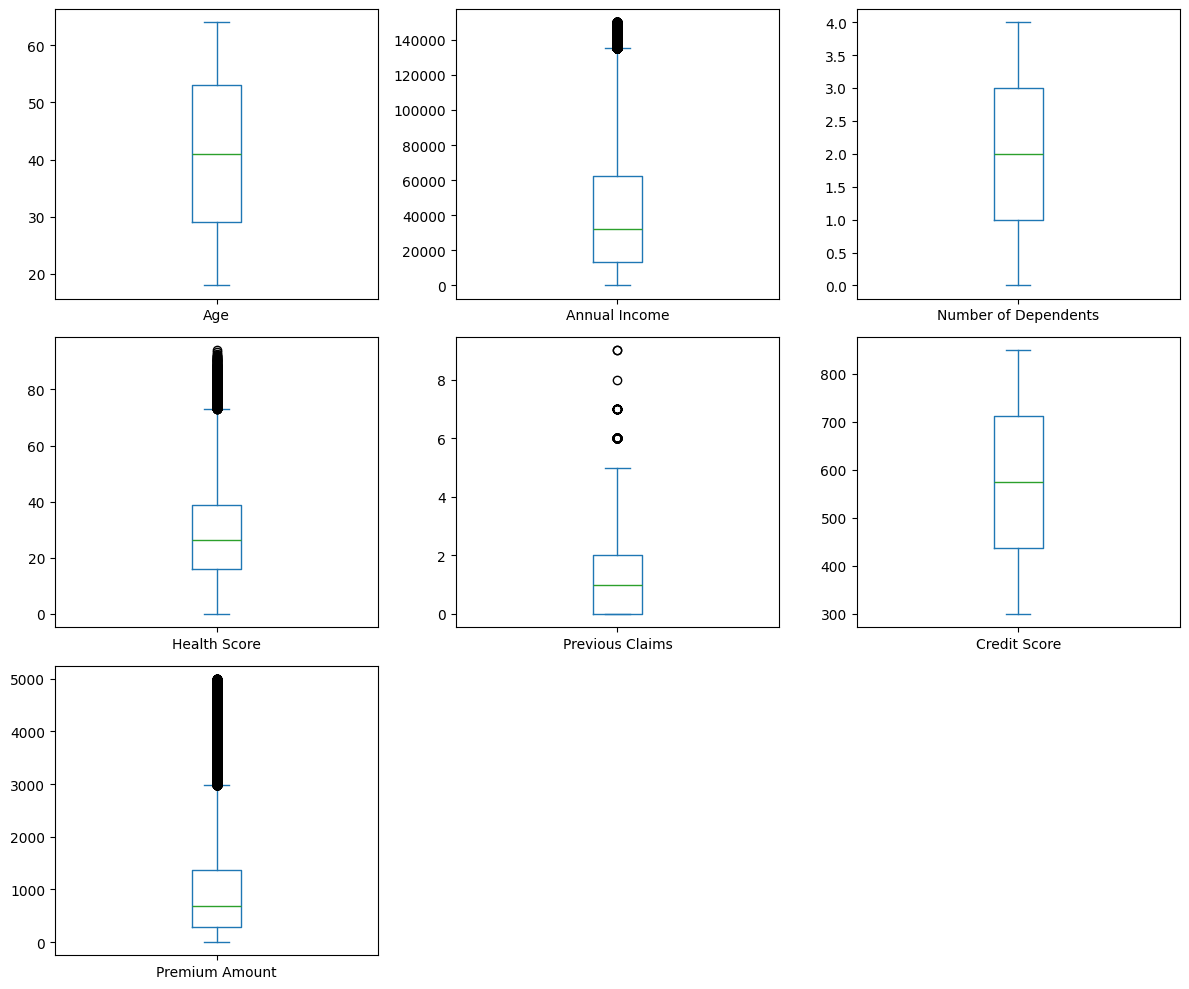

In [40]:
import matplotlib.pyplot as plt

df.select_dtypes(include='float64').plot(
    kind='box',
    subplots=True,
    layout=(3, 3),  # 3 rows, 3 columns = 9 subplots possible
    figsize=(12, 10),
    sharex=False,
    sharey=False
)
plt.tight_layout()
plt.show()


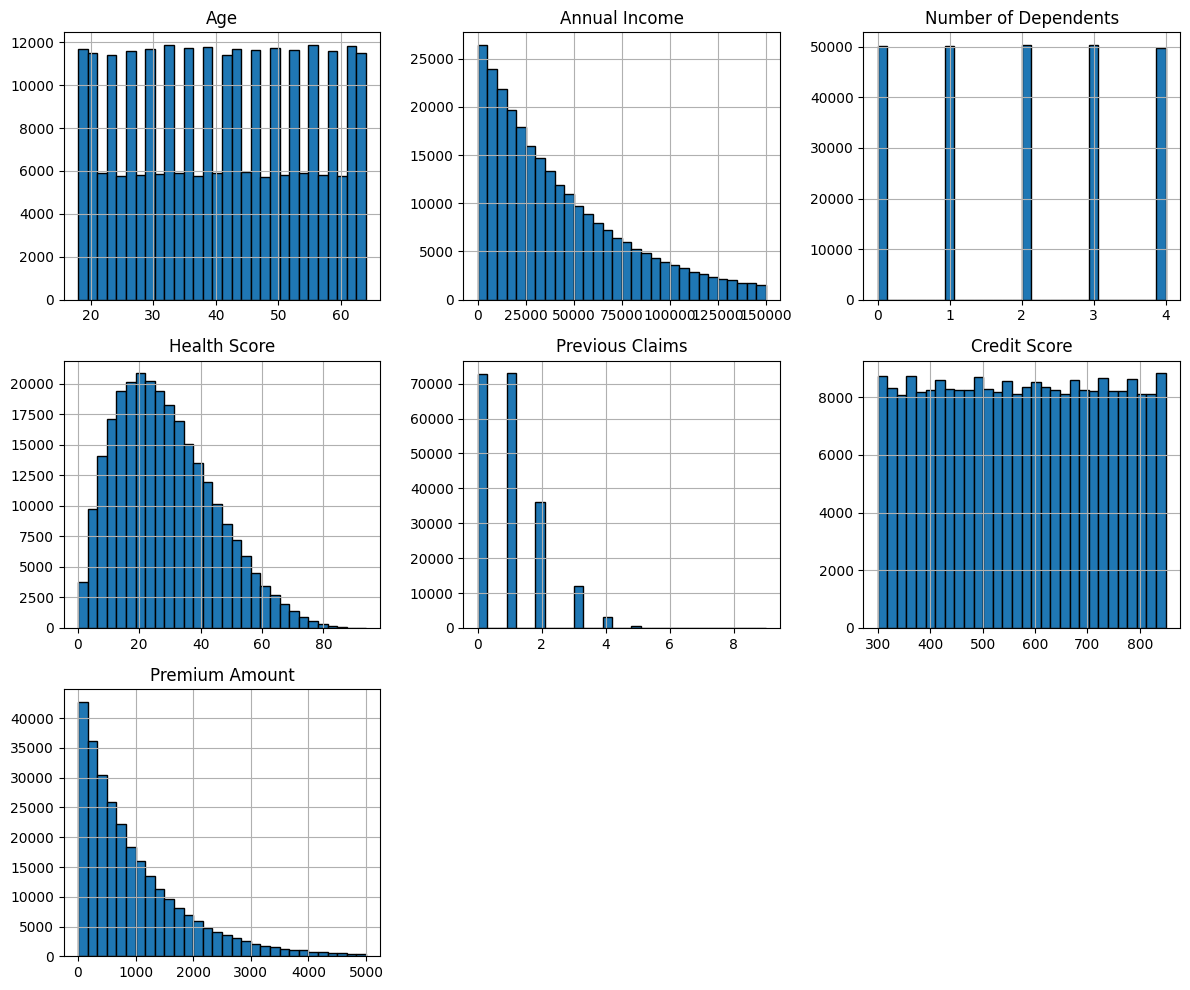

In [41]:
# Plot histograms for all numeric columns
df.select_dtypes(include='float64').hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()


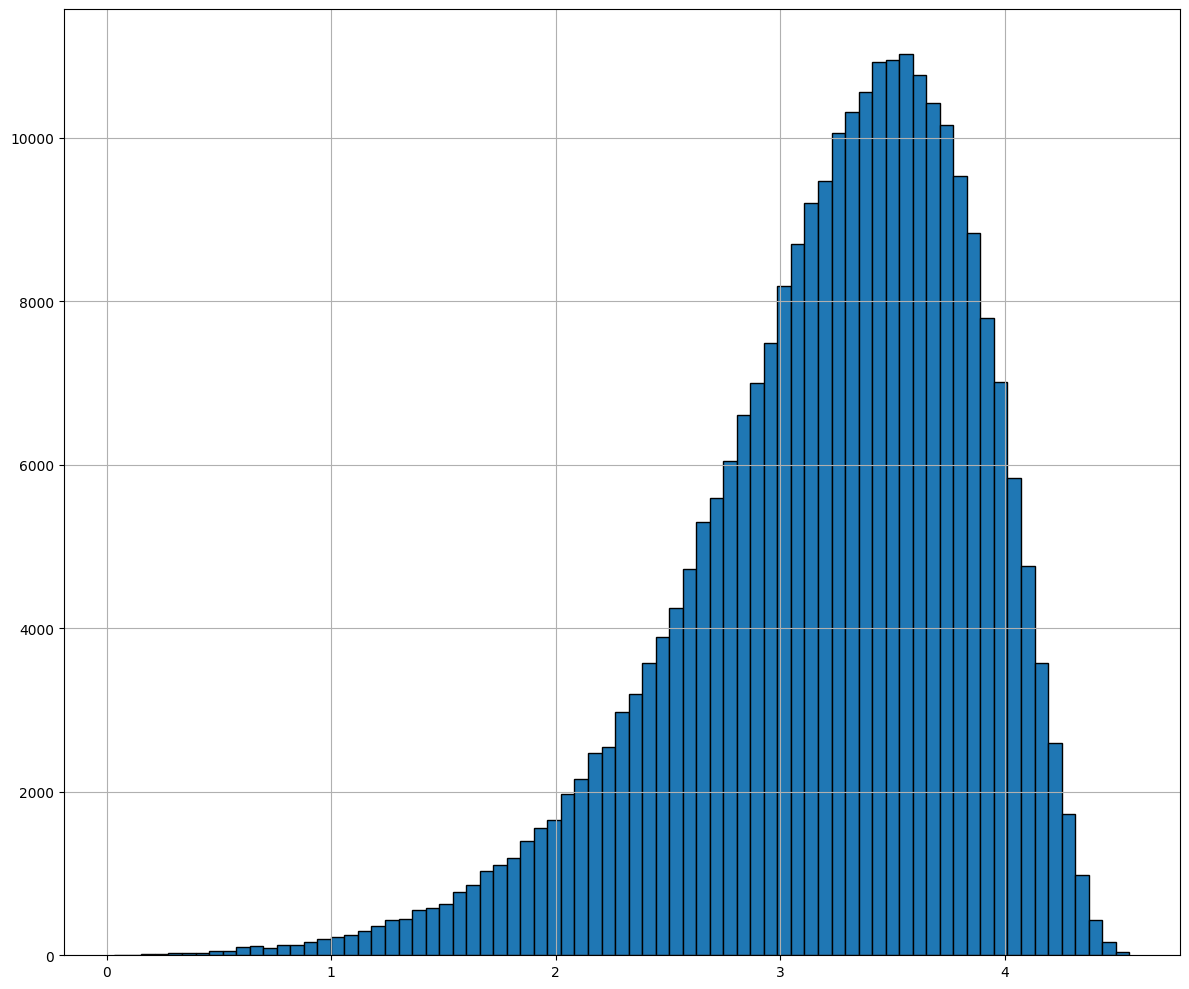

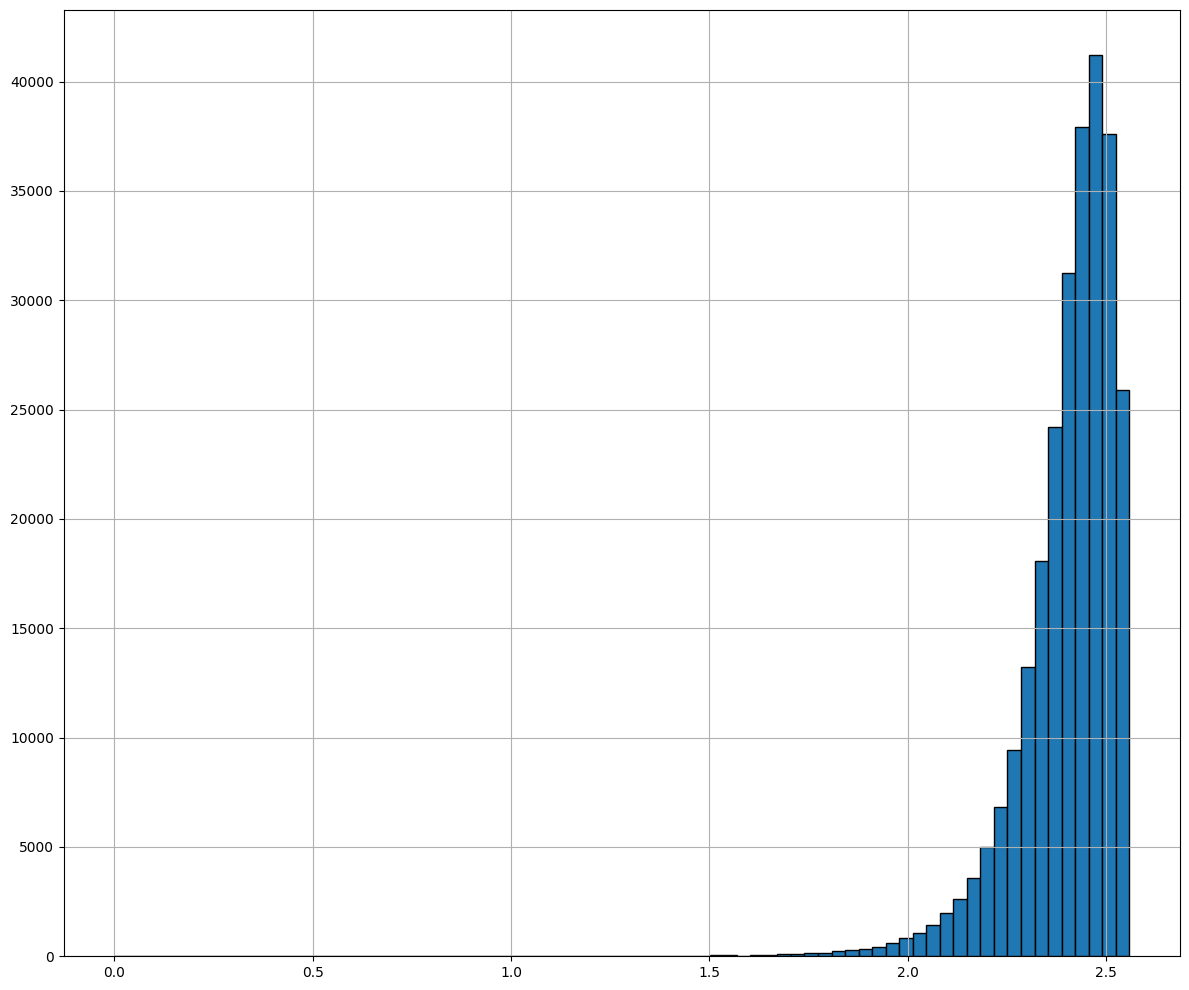

In [56]:
import numpy as np
df['log_health_score'] = np.log1p(df['Health Score'])
df['log_health_score'].hist(figsize=(12, 10), bins=75, edgecolor='black')
plt.tight_layout()
plt.show()
df['log_income'] = np.log1p(df['Annual Income'])
df['log_income'].hist(figsize=(12, 10), bins=75, edgecolor='black')
plt.tight_layout()
plt.show()




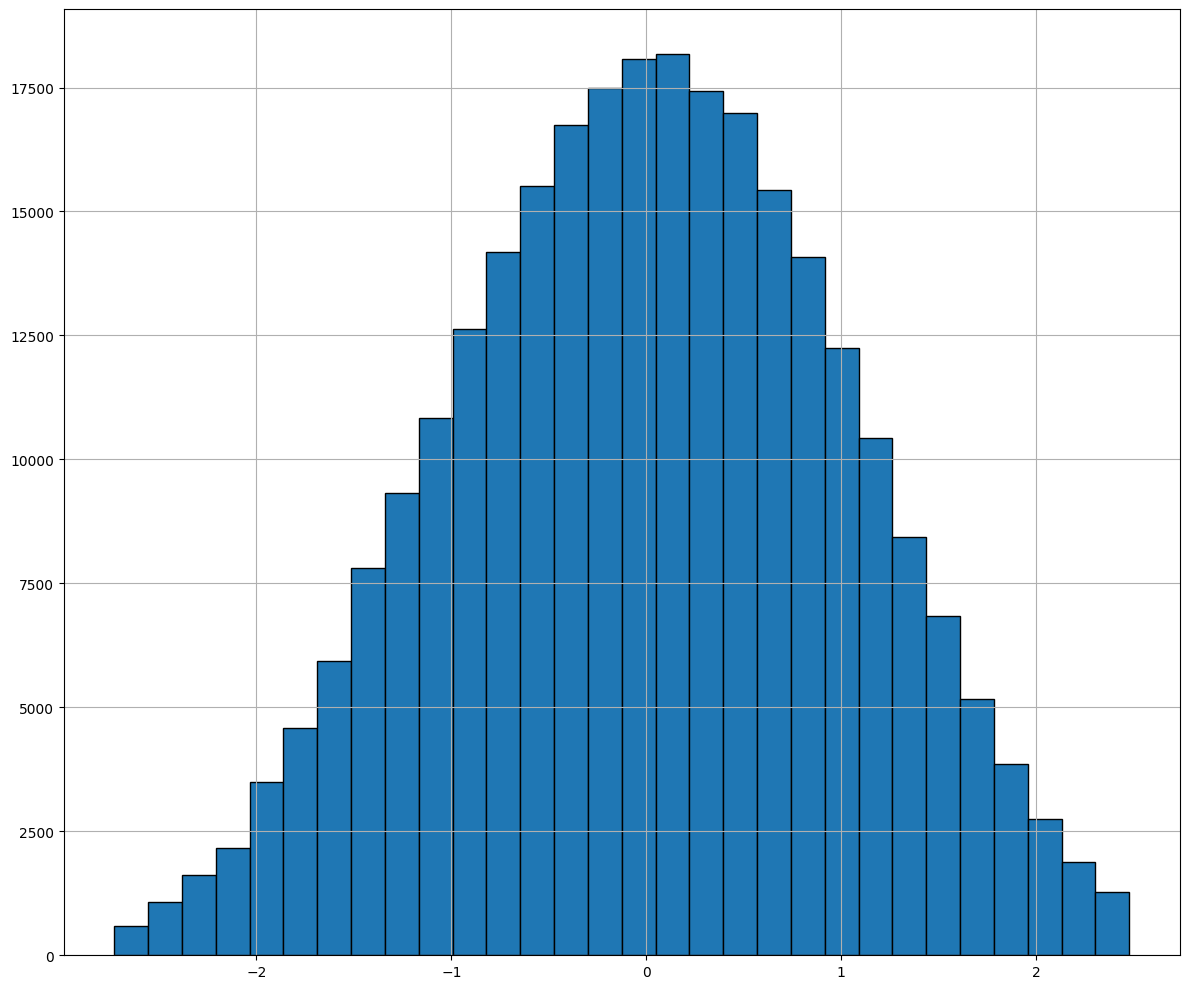

Lambda used for Premium Amount: 0.284865102763534


In [53]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df['premium_transformed'] = pt.fit_transform(df[['Premium Amount']])
df['premium_transformed'].hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()
print("Lambda used for Premium Amount:", pt.lambdas_[0])

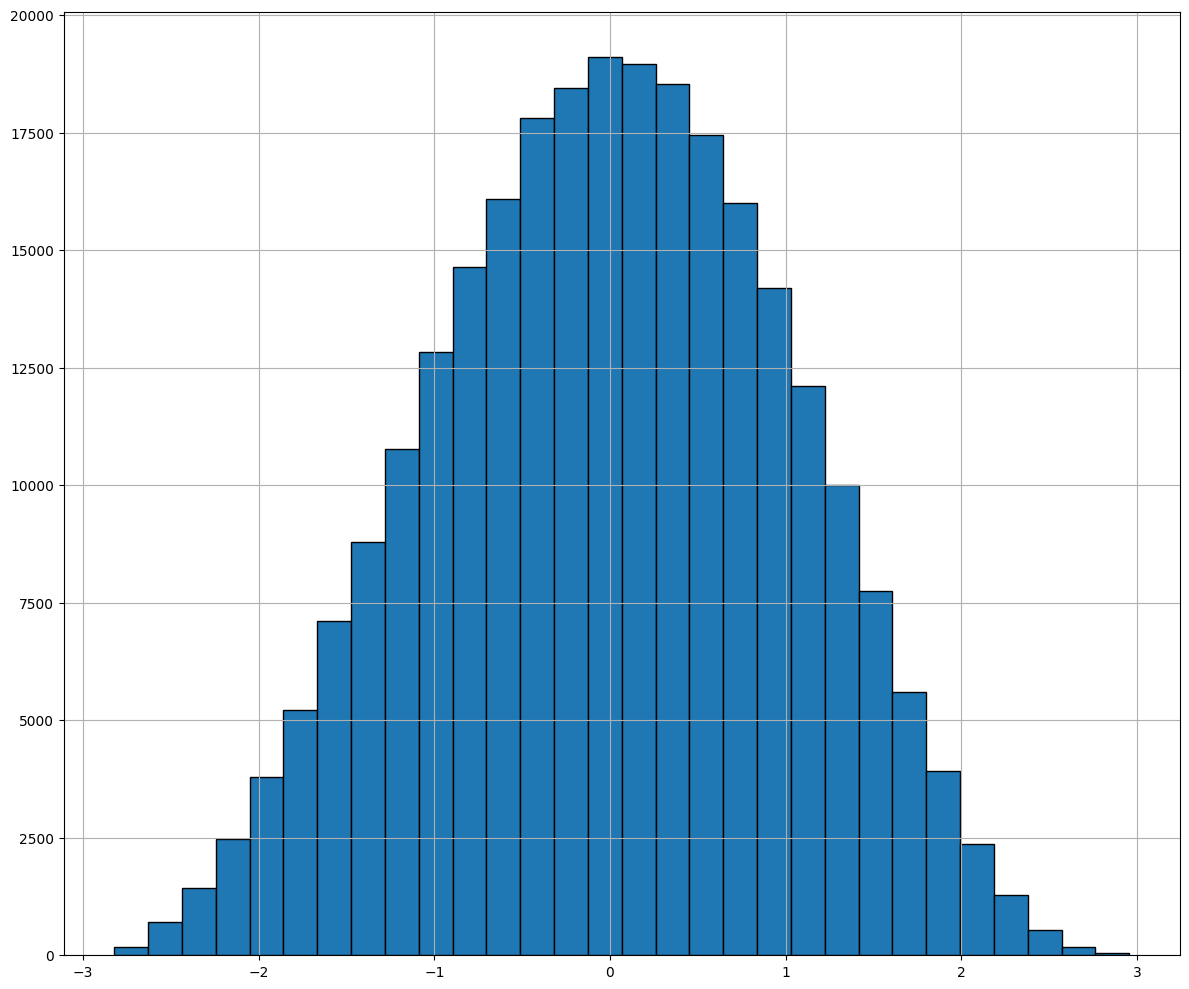

Lambda used for Health Score: 0.4856843546125941


In [54]:
pt = PowerTransformer(method='yeo-johnson')
df['health_score_transformed'] = pt.fit_transform(df[['Health Score']])
df['health_score_transformed'].hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()
print("Lambda used for Health Score:", pt.lambdas_[0])

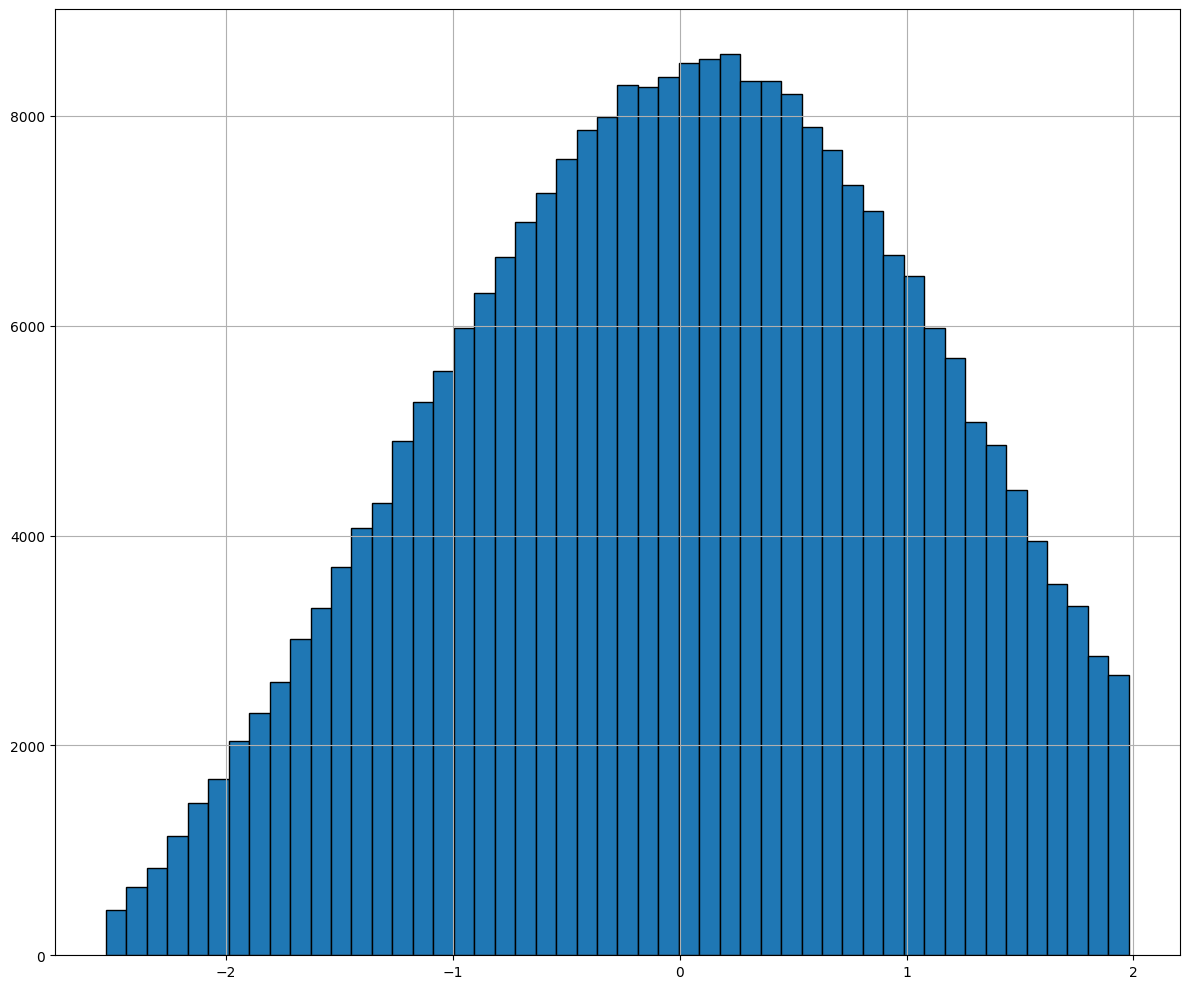

Lambda used for Annual Income: 4.455643525872436


In [57]:
pt = PowerTransformer(method='yeo-johnson')
df['annual_income_transformed'] = pt.fit_transform(df[['Annual Income']])
df['annual_income_transformed'].hist(figsize=(12, 10), bins=50, edgecolor='black')
plt.tight_layout()
plt.show()
print("Lambda used for Annual Income:", pt.lambdas_[0])

In [58]:
print(df.columns)

Index(['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Premium Amount',
       'Policy Start Date', 'Customer Feedback', 'Smoking Status',
       'Exercise Frequency', 'Property Type', 'log_premium',
       'log_annual_income', 'log_health_score', 'premium_transformed',
       'health_score_transformed', 'annual_income_transformed', 'log_income'],
      dtype='object')
